# Metric quality matrix

Scores metrics against corpus-size correlation, word-entropy correlation, and grouping checks (family/genus, script, morphological typology). All metrics evaluated on segmented languages (Morphynet excluded).

In [5]:
from __future__ import annotations

from itertools import combinations
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd()
if not (ROOT / 'results').exists():
    ROOT = Path.cwd().parents[1]

sys.path.insert(0, str(ROOT / 'notebooks' / 'scripts'))
import graph_export

DATA_PATH = ROOT / 'results' / '3_analyze' / 'total_results.csv'
USE_SQUARED_DISTANCE = True
WEIGHT_GROUPS = False
MIN_GROUP_SIZE = 2
SCRIPT_GROUP_COLUMN = 'script'

plt.rcParams['figure.dpi'] = 130

df_raw = pd.read_csv(DATA_PATH)
identity_cols = ['lang', 'script', 'script_type', 'language_name', 'family', 'genus', 'typology']

corpus_metrics = {
    'Word entropy': 'token_frequency_entropy',
    'Word TTR': 'type_token_ratio',
    'Information in word structure': 'compress_reduction_pct',
}
morph_metrics = {
    'Morpheme entropy weighted': 'morph_entropy',
    'Morpheme entropy to word types': 'morph_type_entropy',
    'Morpheme TTR': 'morph_ttr',
    'Average morphemes per word type': 'avg_morphs_per_word',
    'Compounding index': 'compounding_index',
    'Affix deviation': 'affix_deviation',
    'Affix entropy': 'affix_entropy',
}

all_metric_catalog = pd.DataFrame(
    [{'metric': n, 'column': c, 'category': 'Corpus'} for n, c in corpus_metrics.items()] +
    [{'metric': n, 'column': c, 'category': 'Morph'} for n, c in morph_metrics.items()]
)

print(f'Loaded {len(df_raw):,} rows, {df_raw["lang"].nunique()} languages')
display(all_metric_catalog)

Loaded 175 rows, 172 languages


,metric,column,category
0,Word entropy,token_frequency_entropy,Corpus
1,Word TTR,type_token_ratio,Corpus
2,Information in word structure,compress_reduction_pct,Corpus
3,Morpheme entropy weighted,morph_entropy,Morph
4,Morpheme entropy to word types,morph_type_entropy,Morph
5,Morpheme TTR,morph_ttr,Morph
6,Average morphemes per word type,avg_morphs_per_word,Morph
7,Compounding index,compounding_index,Morph
8,Affix deviation,affix_deviation,Morph
9,Affix entropy,affix_entropy,Morph


In [6]:
chapter5_language_groups = {
    'Norwegian': ['nno', 'nob', 'nor'],
    'Serbo-Croatian': ['hbs', 'hrv', 'bos', 'srp'],
    'Malay-Indonesian': ['ind', 'msa', 'zsm'],
    'Hindi-Urdu': ['hin', 'urd'],
    'Persian': ['fas', 'pes'],
    'Estonian': ['est', 'ekk'],
    'Latvian': ['lav', 'lvs'],
    'Azerbaijani': ['aze', 'azj'],
    'Uzbek': ['uzb', 'uzn'],
    'Malagasy': ['mlg', 'plt'],
    'Swahili': ['swa', 'swh'],
    'Oriya': ['ori', 'ory'],
    'Tagalog-Filipino': ['tgl', 'fil'],
    'Albanian': ['als', 'sqi'],
    'Punjabi': ['pan', 'pnb'],
    'Czech-Slovak': ['ces', 'slk'],
    'Bulgarian-Macedonian': ['bul', 'mkd'],
    'Mainland Scandinavian': ['dan', 'swe', 'nno', 'nob', 'nor'],
    'East Slavic': ['rus', 'ukr', 'bel'],
    'Ibero-Romance': ['spa', 'por', 'glg'],
    'Oghuz Turkic': ['tur', 'aze', 'azj', 'tuk'],
    'Kipchak Turkic': ['kaz', 'kir', 'tat', 'bak'],
}

def spearman_abs(a, b):
    both = pd.concat([a, b], axis=1).dropna()
    if len(both) < 3 or both.iloc[:, 0].nunique() < 2 or both.iloc[:, 1].nunique() < 2:
        return np.nan
    return abs(both.iloc[:, 0].rank().corr(both.iloc[:, 1].rank()))

def prepare_metric_frame(metric_col, category, segmented_only=False):
    cols = identity_cols + ['segmentor', 'original_token_count', 'token_frequency_entropy']
    if metric_col not in cols:
        cols.append(metric_col)
    frame = df_raw[cols].copy()
    frame['value'] = pd.to_numeric(frame[metric_col], errors='coerce')

    if segmented_only or category == 'Morph':
        frame = frame[frame['segmentor'].notna() & (frame['segmentor'] != 'Morphynet')]

    frame = frame.dropna(subset=['value', 'lang'])
    if frame.empty:
        frame['unit_id'] = pd.Series(dtype='object')
        return frame

    if segmented_only:
        frame['unit_id'] = frame['lang'].astype(str) + '|' + frame['segmentor'].astype(str)
        return frame

    grouped = frame.groupby('lang', as_index=False).agg({
        'value': 'mean', 'script': 'first', 'script_type': 'first',
        'language_name': 'first', 'family': 'first', 'genus': 'first',
        'typology': 'first', 'segmentor': 'first',
        'original_token_count': 'first', 'token_frequency_entropy': 'first',
    })
    grouped['unit_id'] = grouped['lang']
    return grouped

def normalized_values(values):
    values = pd.to_numeric(values, errors='coerce')
    std = (values - values.mean()) / values.std(ddof=0)
    if std.isna().all() or std.max() == std.min():
        return pd.Series(np.nan, index=values.index)
    return (std - std.min()) / (std.max() - std.min())

def clustering_index(frame, group_col=None, groups=None):
    needed_cols = ['unit_id', 'value'] + ([group_col] if group_col else [])
    work = frame[needed_cols].dropna(subset=['unit_id', 'value']).copy()
    if work.empty:
        return {'index': np.nan, 'score': np.nan, 'groups': 0, 'pairs': 0}

    work['normalized'] = normalized_values(work['value'])
    work = work.dropna(subset=['normalized'])

    if groups is None:
        group_map = {str(n): g['unit_id'].tolist() for n, g in work.dropna(subset=[group_col]).groupby(group_col)}
    else:
        group_map = groups

    unit_to_val = work.set_index('unit_id')['normalized'].to_dict()
    group_distances, group_weights, pair_total = [], [], 0

    for unit_ids in group_map.values():
        vals = [unit_to_val[u] for u in unit_ids if u in unit_to_val]
        if len(vals) < MIN_GROUP_SIZE:
            continue
        dists = [(abs(l - r) ** 2 if USE_SQUARED_DISTANCE else abs(l - r)) for l, r in combinations(vals, 2)]
        if not dists:
            continue
        group_distances.append(float(np.mean(dists)))
        group_weights.append(len(dists) if WEIGHT_GROUPS else 1)
        pair_total += len(dists)

    if not group_distances:
        return {'index': np.nan, 'score': np.nan, 'groups': 0, 'pairs': 0}

    idx = float(np.average(group_distances, weights=group_weights))
    return {'index': idx, 'score': 1 - idx, 'groups': len(group_distances), 'pairs': pair_total}

def family_genus_score(frame):
    fam = clustering_index(frame, group_col='family')
    gen = clustering_index(frame, group_col='genus')
    vals = [v for v in [fam['index'], gen['index']] if pd.notna(v)]
    idx = float(np.mean(vals)) if vals else np.nan
    return {'index': idx, 'score': 1 - idx if pd.notna(idx) else np.nan,
            'groups': fam['groups'] + gen['groups'], 'pairs': fam['pairs'] + gen['pairs']}

def compute_score_matrix(metric_catalog, segmented_only=False):
    row_order = ['Correlation with original token count', 'Correlation with word entropy', 'Family/genus grouping',
                 'Script grouping', 'Morphological typology grouping']
    scores = pd.DataFrame(index=row_order, columns=metric_catalog['metric'], dtype=float)

    for item in metric_catalog.itertuples(index=False):
        frame = prepare_metric_frame(item.column, item.category, segmented_only=segmented_only)
        if frame.empty:
            continue
        scores.loc['Correlation with original token count', item.metric] = spearman_abs(frame['value'], frame['original_token_count'])
        scores.loc['Correlation with word entropy', item.metric] = spearman_abs(frame['value'], frame['token_frequency_entropy'])
        for row_name, result in [
            ('Family/genus grouping', family_genus_score(frame)),
            ('Script grouping', clustering_index(frame, group_col=SCRIPT_GROUP_COLUMN)),
            ('Morphological typology grouping', clustering_index(frame, group_col='typology')),
        ]:
            scores.loc[row_name, item.metric] = result['score']
    return scores

graph_export: saved morphology_grouping.pdf


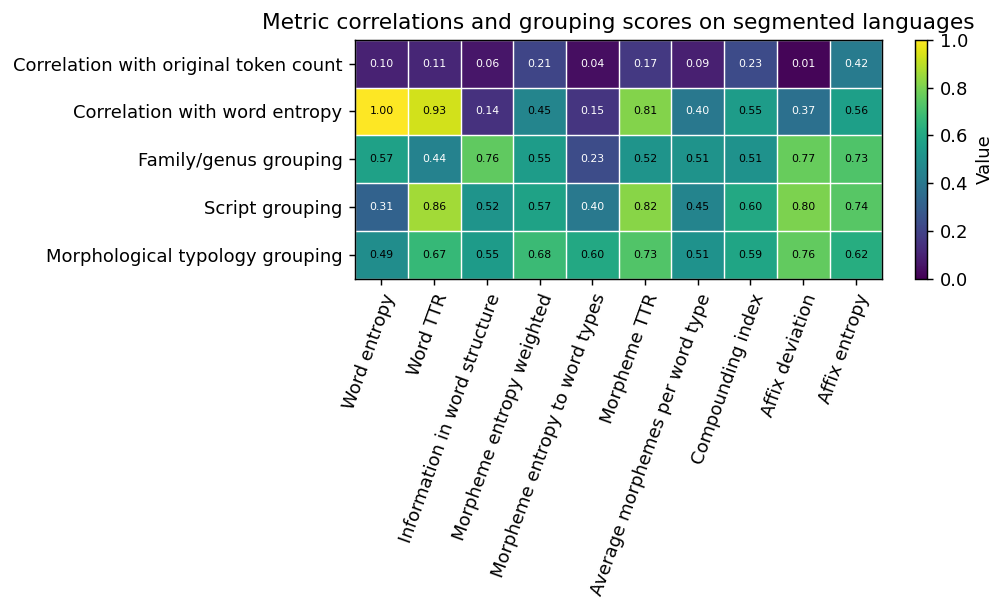

In [7]:
scores = compute_score_matrix(all_metric_catalog, segmented_only=True)

# Stretch grouping rows into [0,1] for better color contrast
stretched = scores.copy()
grouping_rows = stretched.index.str.contains('grouping', case=False, regex=False)
stretched.loc[grouping_rows] = ((stretched.loc[grouping_rows] - 0.8) / 0.2).clip(0, 1)

fig_width = max(8, 0.52 * scores.shape[1])
fig, ax = plt.subplots(figsize=(fig_width, 4.8))
image = ax.imshow(stretched.to_numpy(dtype=float), cmap='viridis', vmin=0, vmax=1, aspect='auto')

ax.set_xticks(np.arange(scores.shape[1]))
ax.set_yticks(np.arange(scores.shape[0]))
ax.set_xticklabels(scores.columns, rotation=70, ha='right', rotation_mode='anchor')
ax.set_yticklabels(scores.index)
ax.set_title('Metric correlations and grouping scores on segmented languages')

for r in range(scores.shape[0]):
    for c in range(scores.shape[1]):
        val = stretched.iat[r, c]
        if pd.notna(val):
            ax.text(c, r, f'{val:.2f}', ha='center', va='center', fontsize=6,
                    color='white' if val < 0.45 else 'black')

ax.set_xticks(np.arange(-0.5, scores.shape[1], 1), minor=True)
ax.set_yticks(np.arange(-0.5, scores.shape[0], 1), minor=True)
ax.grid(which='minor', color='white', linestyle='-', linewidth=0.8)
ax.tick_params(which='minor', bottom=False, left=False)
fig.colorbar(image, ax=ax, label='Value')
fig.tight_layout()

graph_export.save('morphology_grouping', fig)
plt.show()

In [9]:
# --- Grouping framework tests ---
import math

def _make_frame(unit_ids, values, group_col_name="group", group_labels=None):
    d = {"unit_id": unit_ids, "value": values}
    if group_labels is not None:
        d[group_col_name] = group_labels
    return pd.DataFrame(d)

passed, failed = 0, 0

def check(name, condition):
    global passed, failed
    if condition:
        passed += 1
    else:
        failed += 1
        print(f"  FAIL: {name}")

# normalized_values
normed = normalized_values(pd.Series([10, 20, 30, 40, 50]))
check("norm min=0", abs(normed.min()) < 1e-10)
check("norm max=1", abs(normed.max() - 1) < 1e-10)

check("norm constant→NaN", normalized_values(pd.Series([5, 5, 5])).isna().all())

normed2 = normalized_values(pd.Series([100, 200]))
check("norm two vals: 0 and 1", abs(normed2.iloc[0]) < 1e-10 and abs(normed2.iloc[1] - 1) < 1e-10)

# clustering_index: identical values → score=1
frame1 = _make_frame(["a","b","c","d"], [10,10,20,20], group_labels=["G1","G1","G2","G2"])
r1 = clustering_index(frame1, group_col="group")
check("identical within-group → score=1", abs(r1["score"] - 1.0) < 1e-10)
check("identical within-group → index=0", abs(r1["index"]) < 1e-10)
check("2 groups", r1["groups"] == 2)
check("2 pairs", r1["pairs"] == 2)

# full-range group → score=0
frame2 = _make_frame(["a","b"], [0, 100], group_labels=["G","G"])
r2 = clustering_index(frame2, group_col="group")
check("full range → score=0", abs(r2["score"]) < 1e-10)

# explicit groups dict
frame3 = _make_frame(["a","b","c"], [5, 5, 100])
r3 = clustering_index(frame3, groups={"close": ["a","b"]})
check("explicit groups → score=1", abs(r3["score"] - 1.0) < 1e-10)

# singleton group skipped
frame4 = _make_frame(["a","b","c"], [1,2,3], group_labels=["G1","G1","solo"])
r4 = clustering_index(frame4, group_col="group")
check("singleton skipped", r4["groups"] == 1)

# empty frame
frame5 = pd.DataFrame({"unit_id": [], "value": [], "group": []})
r5 = clustering_index(frame5, group_col="group")
check("empty → NaN", math.isnan(r5["index"]))

# 3-element group → 3 pairs (need distinct values so normalization works)
frame6 = _make_frame(["a","b","c"], [10,11,12], group_labels=["G","G","G"])
r6 = clustering_index(frame6, group_col="group")
check("3 elements → 3 pairs", r6["pairs"] == 3)

# score == 1 - index
frame7 = _make_frame(["a","b","c","d"], [1,3,10,12], group_labels=["X","X","Y","Y"])
r7 = clustering_index(frame7, group_col="group")
check("score = 1 - index", abs(r7["score"] - (1 - r7["index"])) < 1e-10)

# known numeric: [0, 4, 10]
vals = np.array([0.0, 4.0, 10.0])
mu, sigma = vals.mean(), vals.std(ddof=0)
z = (vals - mu) / sigma
n = (z - z.min()) / (z.max() - z.min())
from itertools import combinations as _c
expected = np.mean([(a - b)**2 for a, b in _c(n, 2)])
frame8 = _make_frame(["a","b","c"], [0, 4, 10], group_labels=["G","G","G"])
r8 = clustering_index(frame8, group_col="group")
check("known numeric index", abs(r8["index"] - expected) < 1e-10)

# family_genus_score (values must vary globally but be same within groups)
frame9 = pd.DataFrame({"unit_id": ["a","b","c","d"], "value": [10,10,20,20],
                        "family": ["F1","F1","F2","F2"], "genus": ["G1","G1","G2","G2"]})
r9 = family_genus_score(frame9)
check("family_genus same within-group → score=1", abs(r9["score"] - 1.0) < 1e-10)
check("family_genus 4 groups", r9["groups"] == 4)

# spearman_abs
check("spearman perfect positive", abs(spearman_abs(pd.Series([1,2,3,4,5]), pd.Series([10,20,30,40,50])) - 1.0) < 1e-10)
check("spearman perfect negative (abs)", abs(spearman_abs(pd.Series([1,2,3,4,5]), pd.Series([50,40,30,20,10])) - 1.0) < 1e-10)
check("spearman too few → NaN", math.isnan(spearman_abs(pd.Series([1,2]), pd.Series([3,4]))))
check("spearman constant → NaN", math.isnan(spearman_abs(pd.Series([5,5,5]), pd.Series([1,2,3]))))

print(f"\n{passed} passed, {failed} failed")


21 passed, 0 failed
